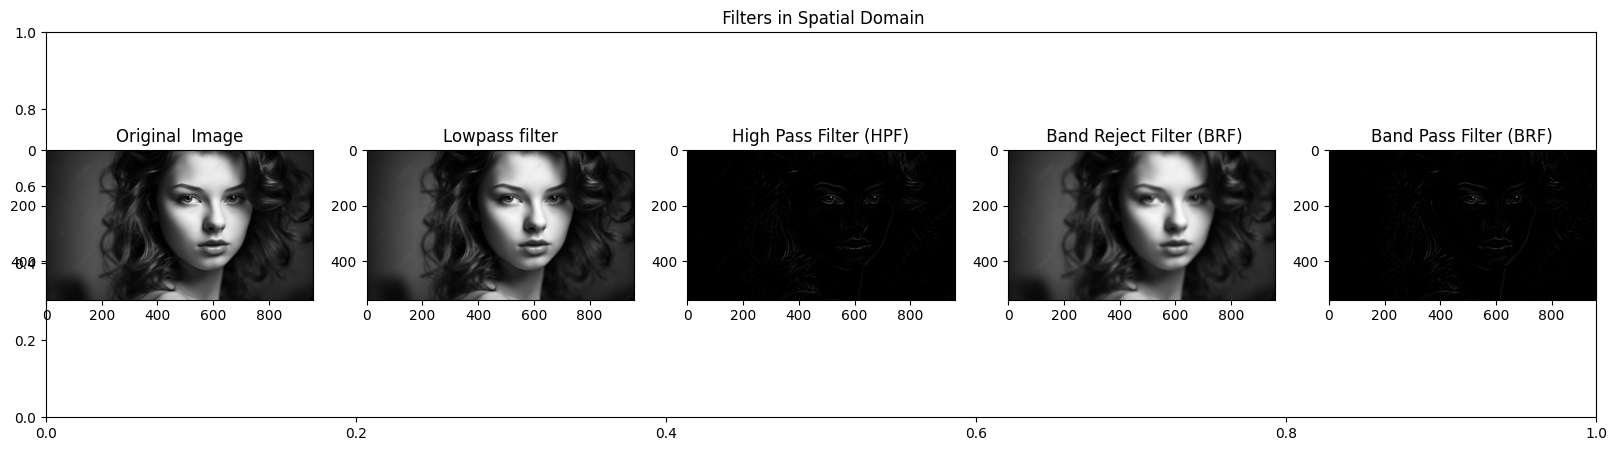

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load image and create Lowpass filter
image = cv2.imread('/content/image.jpg', 0)
# A simple LPF using Gaussian Blur (kernel size 15, sigma 3)
lpf_image_low = cv2.GaussianBlur(image, (15, 15), 3)

# A tighter LPF for the high-end of band filters (kernel size 5, sigma 1)
lpf_image_high = cv2.GaussianBlur(image, (5, 5), 1)

# 2. High Pass Filter (HPF)
# Formula: Original - Lowpass
hpf_image = cv2.subtract(image, lpf_image_low)

# 3. Band Reject Filter (BRF)
# Formula: Lowpass(Low_Cutoff) + Highpass(High_Cutoff)
# First, create the second highpass component
hpf_high_component = cv2.subtract(image, lpf_image_high)

band_reject = cv2.add(lpf_image_low, hpf_high_component)

# 4. Band Pass Filter (BPF)
# Formula: Original - BandReject
band_pass = cv2.subtract(image, band_reject)

# Normalize/Abs to ensure proper viewing
#hpf_image = np.absolute(hpf_image).astype(np.uint8)
#band_pass = np.absolute(band_pass).astype(np.uint8)


plt.figure(figsize=(20, 5))
plt.title(' Filters in Spatial Domain')
plt.subplot(1, 5, 1),
plt.imshow(image,cmap='gray'),
plt.title('Original  Image')
plt.subplot(1, 5, 2), plt.imshow(lpf_image_high,cmap='gray'),
plt.title('Lowpass filter')
plt.subplot(1, 5, 3), plt.imshow(hpf_image,cmap='gray'),
plt.title('High Pass Filter (HPF)')
plt.subplot(1, 5, 4), plt.imshow(band_reject ,cmap='gray'),
plt.title(' Band Reject Filter (BRF)')
plt.subplot(1, 5, 5), plt.imshow(band_pass,cmap='gray'),
plt.title('Band Pass Filter (BRF)')
plt.show()
